# Sales Meeting Charts
Plan to present in monthly sales meetings. <br>
(Old presentation file was `Sales Analysis Meeting.xlsx`)

Source file is `sales_analysis_data.xlsx` (data from old file above). <br>
> Each tab is a year and there's a combined years non-cumulative tab at the end for manual check and entry. <br>
Each year has written sales (`written`), invoiced sales (`invoiced`), and goals per month (`goal`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from openpyxl import load_workbook
from pathlib import Path
data_file = Path('sales_analysis_data.xlsx')
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
wb = load_workbook(data_file, data_only=True)
def read_year(sheet_name):
    ws = wb[sheet_name]
    written  = [ws.cell(row=2, column=2 + i).value for i in range(12)]
    invoiced = [ws.cell(row=3, column=2 + i).value for i in range(12)]
    goal     = [ws.cell(row=4, column=2 + i).value for i in range(12)]
    return written, invoiced, goal
    
years = sorted(int(s) for s in wb.sheetnames if s.isdigit() and len(s) == 4)
data = {}
for yr in years:
    w, inv, g = read_year(str(yr))
    data[yr] = {'written': w, 'invoiced': inv, 'goal': g}
    
incomplete = [yr for yr in years if data[yr]['written'][-1] is None]
current_year = incomplete[-1] if incomplete else years[-1]
months_closed = sum(1 for v in data[current_year]['written'] if v is not None)
print(f'Years = {years}')
print(f'Current Year = {current_year}')
print(f'Current Months = {months_closed}')
df = pd.DataFrame({yr: data[yr]['written'] for yr in data}, index=months)
df.index.name = 'Month'
df

Years = [2023, 2024, 2025, 2026]
Current Year = 2026
Current Months = 5


,2023,2024,2025,2026
Month,,,,
Jan,852827.79,844942.96,1445682.85,955153.67
Feb,1941736.86,1837520.97,2637558.88,1915665.26
Mar,2877487.69,2592888.01,3812147.03,3150003.07
Apr,3609987.30,3662612.72,5027855.31,4513201.07
May,4825078.24,4554326.79,6264607.59,5726527.90
Jun,5866636.13,5701911.73,7193093.03,NaN
Jul,6423941.43,6717868.44,8392742.67,NaN
Aug,7540840.14,7751572.35,9415927.40,NaN
Sep,8338579.68,8712512.12,10465391.08,NaN


## YoY Growth
Year over Year Growth uses written sales because invoiced sales is often delayed (production delays, accounting delays, etc.) <br>
Current year isn't included and only complete years are used. <br>
In addition to YoY we check if the goal was reached (+-).

In [2]:
complete_years = [yr for yr in years if data[yr]['written'][-1] is not None]
year_end = {yr: data[yr]['written'][-1] for yr in complete_years}
year_goal = {yr: data[yr]['goal'][-1] for yr in years}
growth = pd.DataFrame({'Year End Written $': [year_end[y] for y in complete_years],'Goal $': [year_goal[y] for y in complete_years],}, index=complete_years)
growth['Goal Reached'] = growth['Year End Written $'] >= growth['Goal $']
growth['Over or Under $'] = growth['Year End Written $'] - growth['Goal $']
growth['YoY Growth %'] = growth['Year End Written $'].pct_change() * 100
yoy_values = growth['YoY Growth %'].dropna().tolist()
avg_yoy = float(np.mean(yoy_values)) if yoy_values else 0
recent_yoy = yoy_values[-1] if yoy_values else 0
for prev, curr in zip(complete_years[:-1], complete_years[1:]):
    g = (year_end[curr] - year_end[prev]) / year_end[prev] * 100
    print(f'{prev} to {curr} Growth = {g:+.1f}%')

print(f'Average YoY Growth = {avg_yoy:+.1f}%')
print(f'Most Recent YoY Growth = {recent_yoy:+.1f}%')
growth

2023 to 2024 Growth = +15.4%
2024 to 2025 Growth = +8.0%
Average YoY Growth = +11.7%
Most Recent YoY Growth = +8.0%


,Year End Written $,Goal $,Goal Reached,Over or Under $,YoY Growth %
2023,10792586.67,12620000,False,-1827413.33,NaN
2024,12457385.99,12000000,True,457385.99,15.425397
2025,13450969.26,12699999,True,750970.26,7.975857


## Forecast Full Year
To forecast current full year we figure the fraction of sales written for each year at the same month as current year's month.<br>
Then we divded this year's current written sales by the average of the above.

This assumes the same pacing/weight of sales as the average of previous years. Having a heavier early or late year isn't factored in, so this forecast isn't very absolute.<br>
(See monthly bar chart comparison at end for a better visual of the pacing/weight of each year).

In [3]:
n = months_closed
forecast_cy = None
if n == 0:
    print(f'No closed months for {current_year}')
else:
    historical_sales_weight = {}
    for yr in complete_years:
        sales_weight = data[yr]['written'][n-1] / data[yr]['written'][-1]
        historical_sales_weight[yr] = sales_weight
        print(f'Average Sales {yr} = {sales_weight*100:.1f}% of year end sales by end of {months[n-1]}')
    avg_sales_weight = float(np.mean(list(historical_sales_weight.values())))
    closed_cy = data[current_year]['written'][n-1]
    forecast_cy = closed_cy / avg_sales_weight
    print(f'Average Sales % by End of {months[n-1]} = {avg_sales_weight*100:.1f}%')
    print()
    print(f'{current_year} Sales $ by End of {months[n-1]} = ${closed_cy:,.0f}')
    print(f'Forecasted {current_year} Year End = ${forecast_cy:,.0f}')
    print(f'Forecasted {current_year} Year End Goal = ${year_goal[current_year]:,.0f}')
    print(f'Forecasted Over or Under = ${forecast_cy - year_goal[current_year]:+,.0f}')

Average Sales 2023 = 44.7% of year end sales by end of May
Average Sales 2024 = 36.6% of year end sales by end of May
Average Sales 2025 = 46.6% of year end sales by end of May
Average Sales % by End of May = 42.6%

2026 Sales $ by End of May = $5,726,528
Forecasted 2026 Year End = $13,438,323
Forecasted 2026 Year End Goal = $13,981,626
Forecasted Over or Under = $-543,303


## Realistic Next-Year Goal
Goals are set by parent company, but just for personal fun... <br>
> "Realistic" Next-Year Goal = forecasted year-end grown by the midpoint of two scenarios (most-recent YoY growth and average YoY growth) rounded to the nearest $100k. <br>
A stretch figure (`avg_yoy + 3`) is figured for reference but is not used to set goals.<br>
Monthly goals is shaped using the average historical goal-pacing curve so the green next-year line follows a "realistic" seasonal shape rather than a straight ramp.

In [4]:
next_year = current_year + 1
goal_next = None
goal_next_monthly = None
if forecast_cy is None:
    print(f'{current_year} forecast not found')
else:
    rec = forecast_cy * (1 + recent_yoy/100)
    avg = forecast_cy * (1 + avg_yoy/100)
    stretch = forecast_cy * (1 + (avg_yoy + 3)/100)
    goal_next = round((rec + avg) / 2 / 100_000) * 100_000

    print(f'Recent ({recent_yoy:+.1f}%) = ${rec:,.0f}')
    print(f'Average ({avg_yoy:+.1f}%) = ${avg:,.0f}')
    print(f'Stretch ({avg_yoy+3:+.1f}%) = ${stretch:,.0f}')
    print()
    print(f'Realistic {next_year} Goal = ${goal_next:,.0f}')
    
    goal_sales = pd.DataFrame({yr: [data[yr]['goal'][m] / data[yr]['goal'][-1] for m in range(12)] for yr in years}, index=months,)
    avg_goal_sales = goal_sales.mean(axis=1)
    goal_next_monthly = (avg_goal_sales * goal_next).values

Recent (+8.0%) = $14,510,144
Average (+11.7%) = $15,010,691
Stretch (+14.7%) = $15,413,840

Realistic 2027 Goal = $14,800,000


## Combined Years Chart
Cumulative line chart for quick visual comparison. More detailed visuals are shown w/ individual charts below.

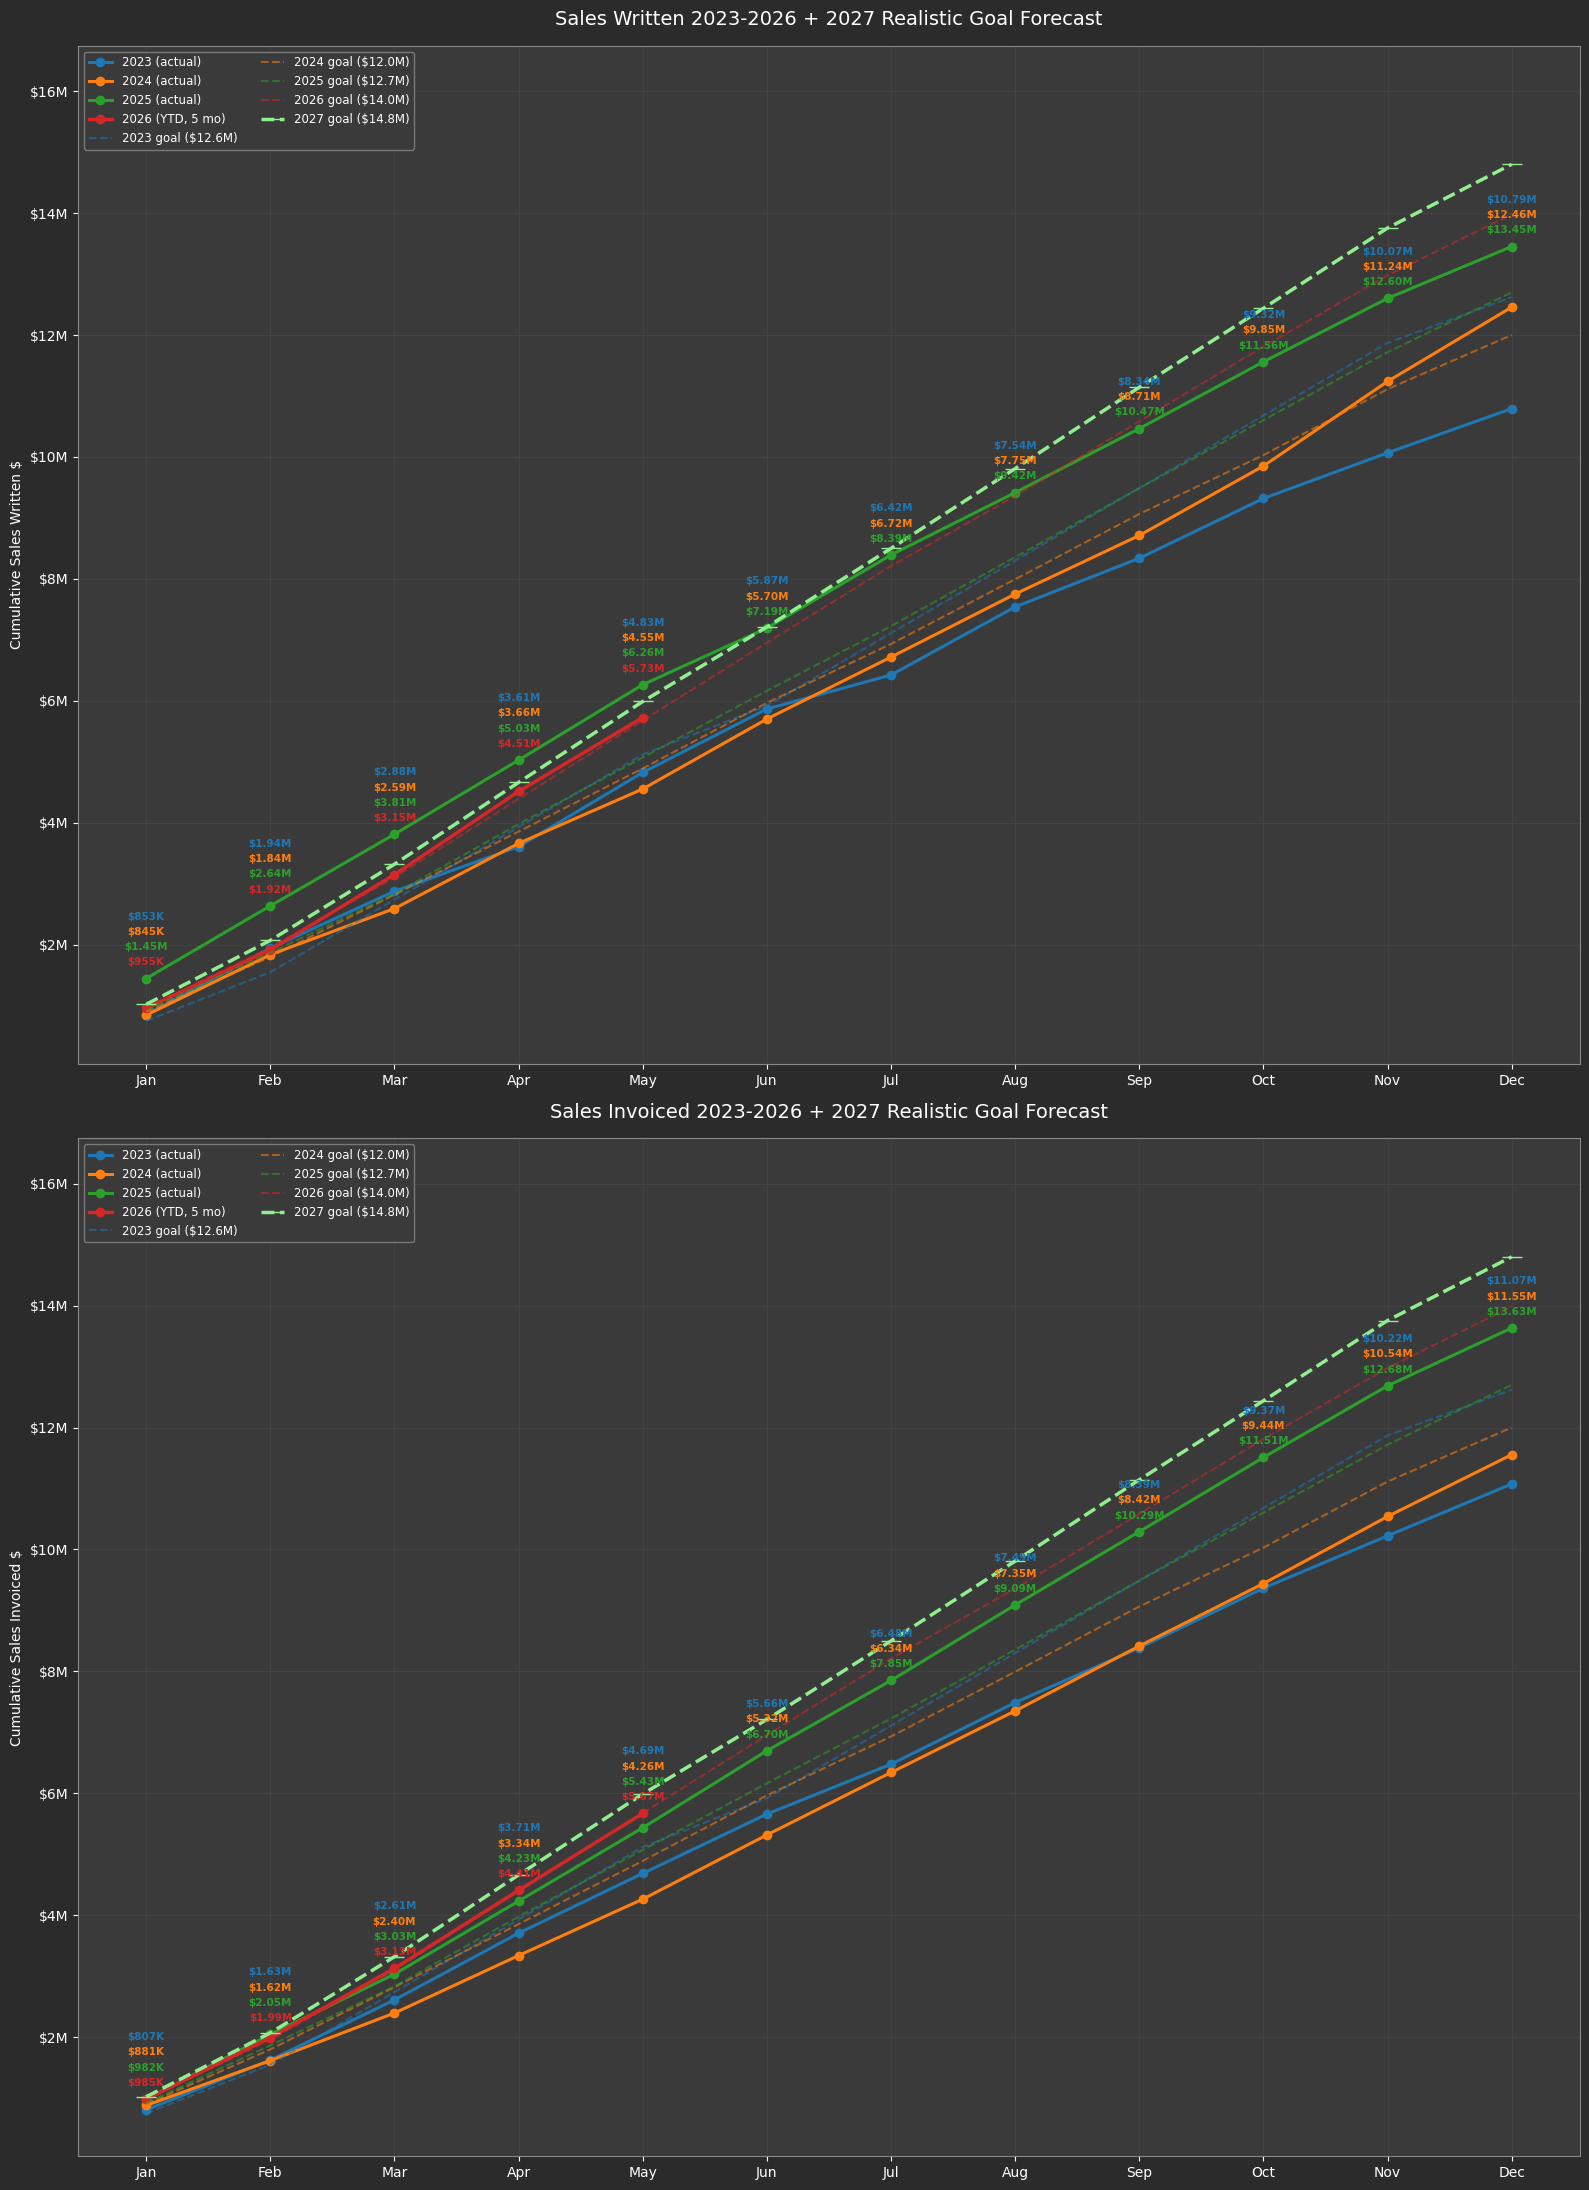

In [5]:
plt.rcParams['figure.facecolor'] = '#2b2b2b'
plt.rcParams['axes.facecolor'] = '#3a3a3a'
plt.rcParams['axes.edgecolor'] = '#888'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['grid.color'] = '#555'
plt.rcParams['axes.titlecolor'] = 'white'

x = np.arange(12)
cmap = plt.get_cmap('tab10')
colors = {yr: cmap(i % 10) for i, yr in enumerate(years)}
def fmt(v):
    return f'${v/1e6:,.2f}M' if v >= 1e6 else f'${v/1e3:,.0f}K'
    
fig, axes = plt.subplots(2, 1, figsize=(16, 22))
for ax, metric in zip(axes, ['written', 'invoiced']):
    for yr in years:
        series = data[yr][metric]
        pts = [v for v in series if v is not None]
        if not pts:
            continue
        if yr == current_year and len(pts) < 12:
            ax.plot(x[:len(pts)], pts, marker='o', linewidth=2.5, color=colors[yr], label=f'{yr} (YTD, {len(pts)} mo)')
        else:
            ax.plot(x, series, marker='o', linewidth=2.2, color=colors[yr], label=f'{yr} (actual)')
    for yr in years:
        goal_traj = data[yr]['goal']
        if all(v is not None for v in goal_traj):
            ax.plot(x, goal_traj, linestyle='--', linewidth=1.5, color=colors[yr], alpha=0.55, label=f'{yr} goal (${goal_traj[-1]/1e6:.1f}M)')
    if goal_next is not None:
        ax.plot(x, goal_next_monthly, linestyle='--', linewidth=2.5, color='lightgreen', marker='_', markersize=14, label=f'{next_year} goal (${goal_next/1e6:.1f}M)')
    for month_idx in range(12):
        entries = []
        for yr in years:
            v = data[yr][metric][month_idx]
            if v is not None:
                entries.append((yr, v))
        if not entries:
            continue
        anchor_y = max(v for _, v in entries)
        entries.reverse()
        for stack_pos, (yr, v) in enumerate(entries):
            offset_y = 8 + stack_pos * 11
            ax.annotate(fmt(v), xy=(month_idx, anchor_y), xytext=(0, offset_y), textcoords='offset points', color=colors[yr], fontsize=7.5, ha='center', va='bottom', fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(months)
    ax.set_title(f'Sales {metric.capitalize()} {years[0]}-{years[-1]} + {next_year} Realistic Goal Forecast', fontsize=14, pad=15)
    ax.set_ylabel(f'Cumulative Sales {metric.capitalize()} $')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v/1e6:.0f}M'))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', facecolor='#3a3a3a', edgecolor='#888', labelcolor='white', ncol=2, fontsize=8.5)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.08)
plt.tight_layout()
plt.show()

## Individual Charts Per Year
Cumulative written and invoiced line charts. Table shows the non-cumulative values in ().

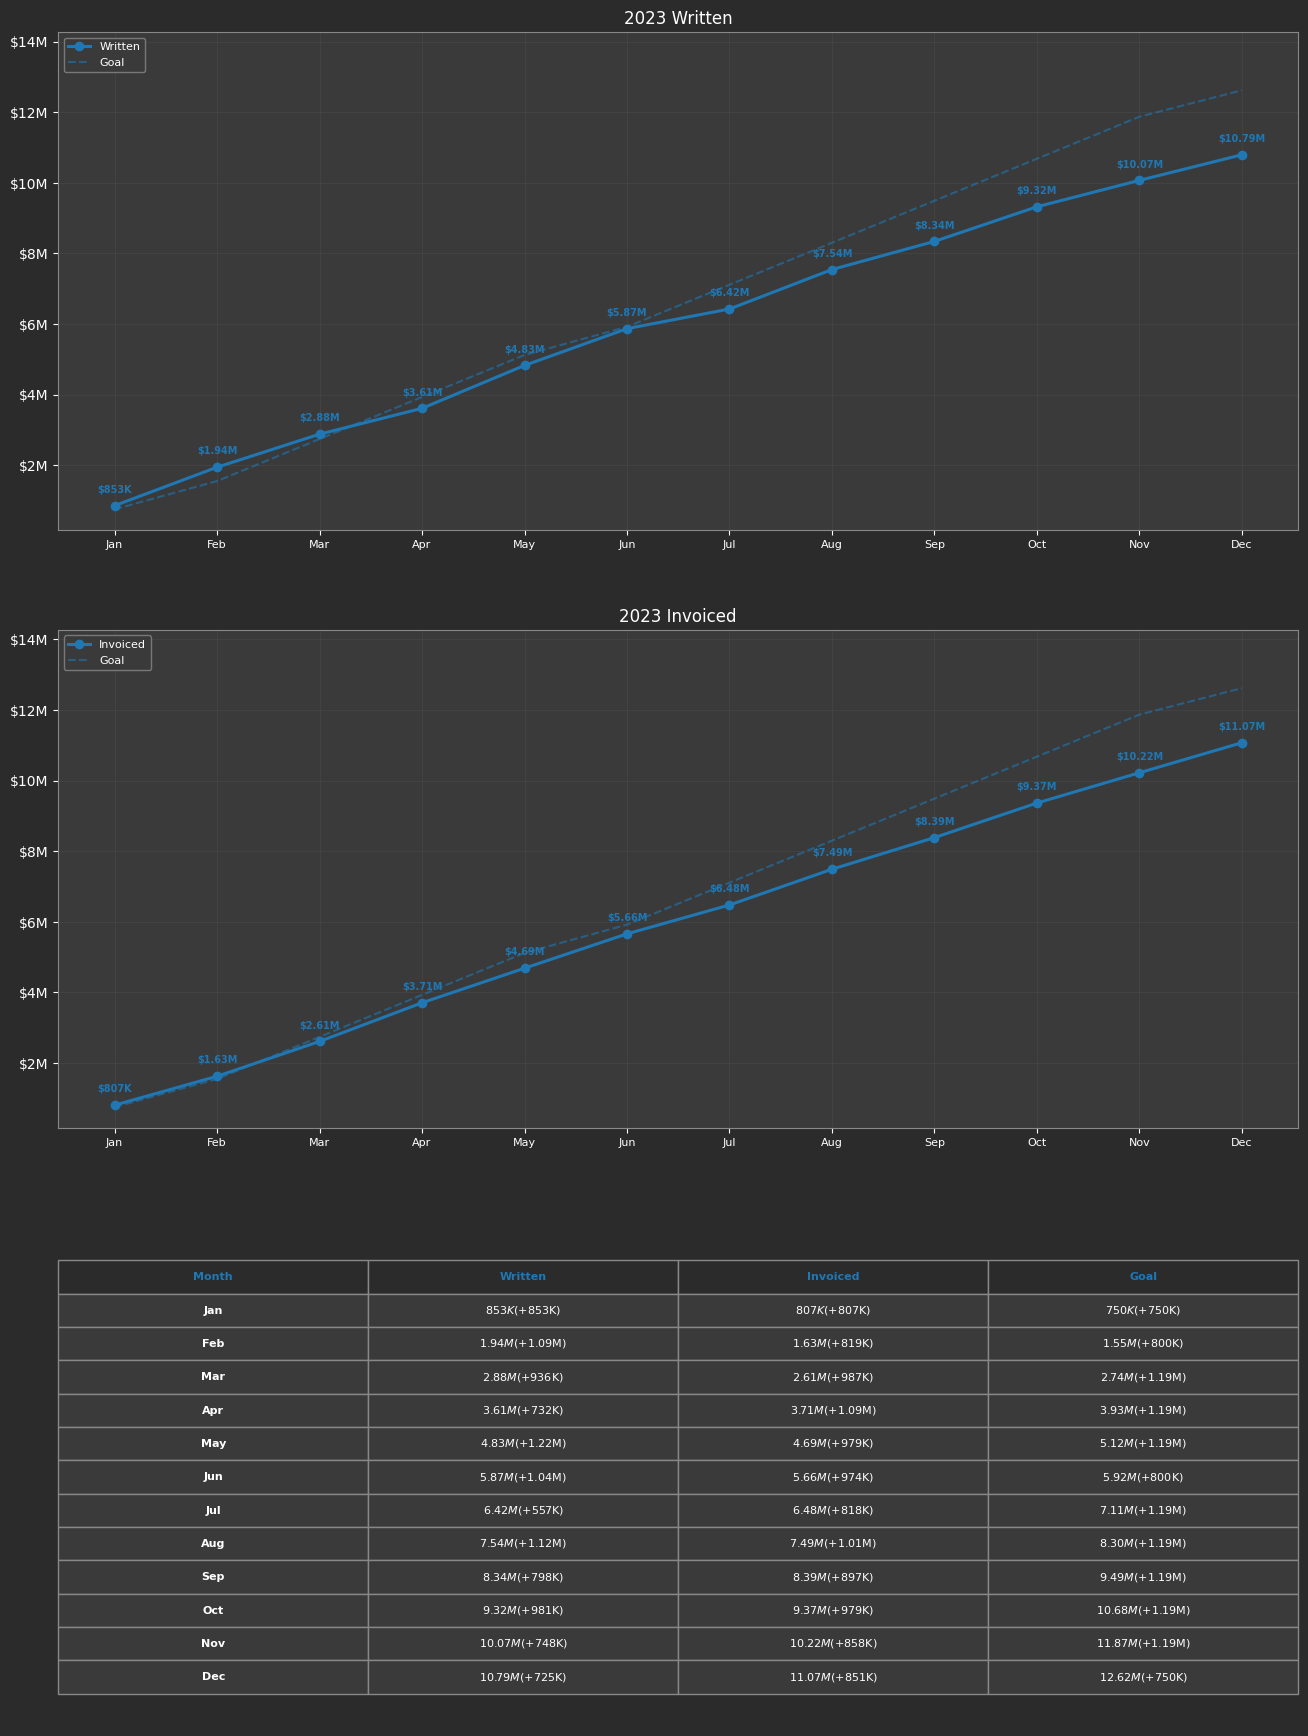

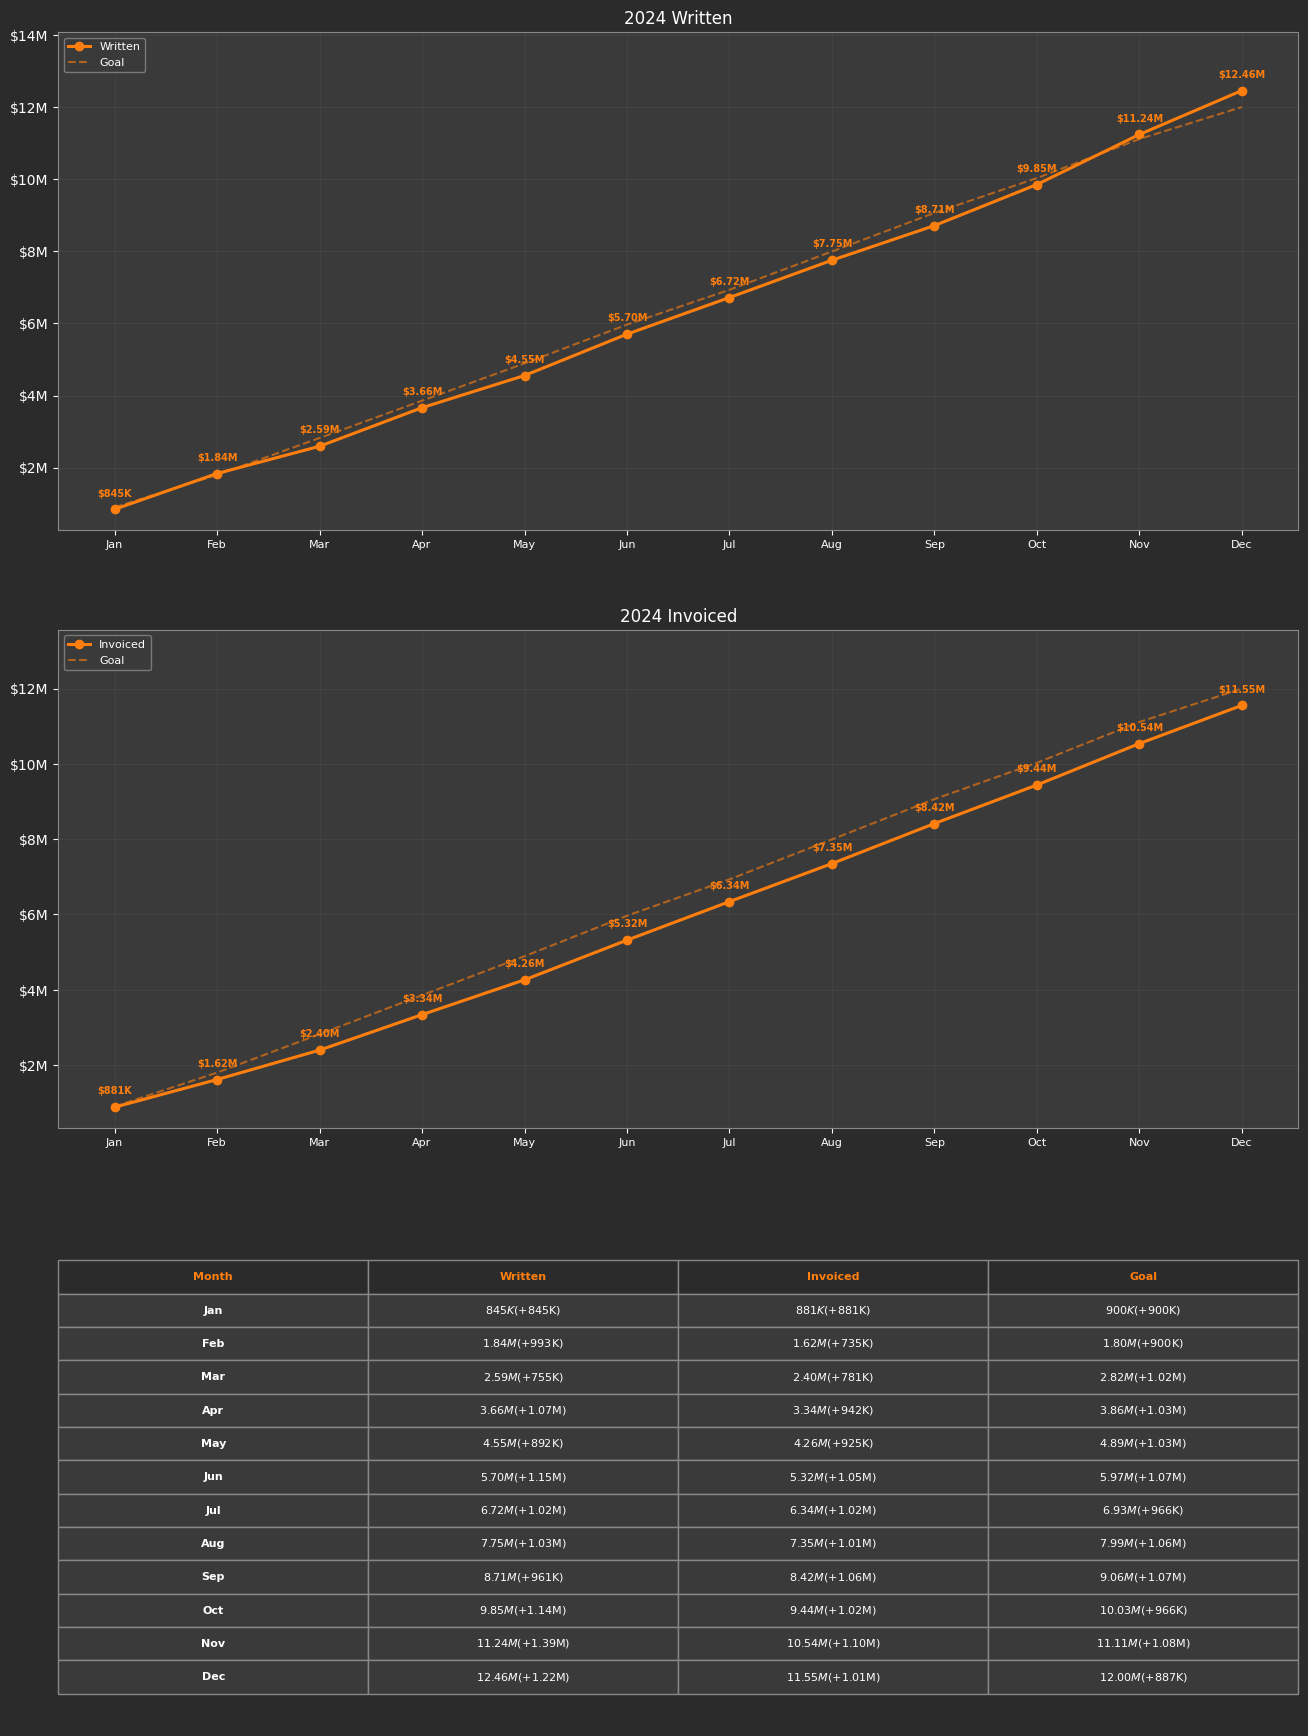

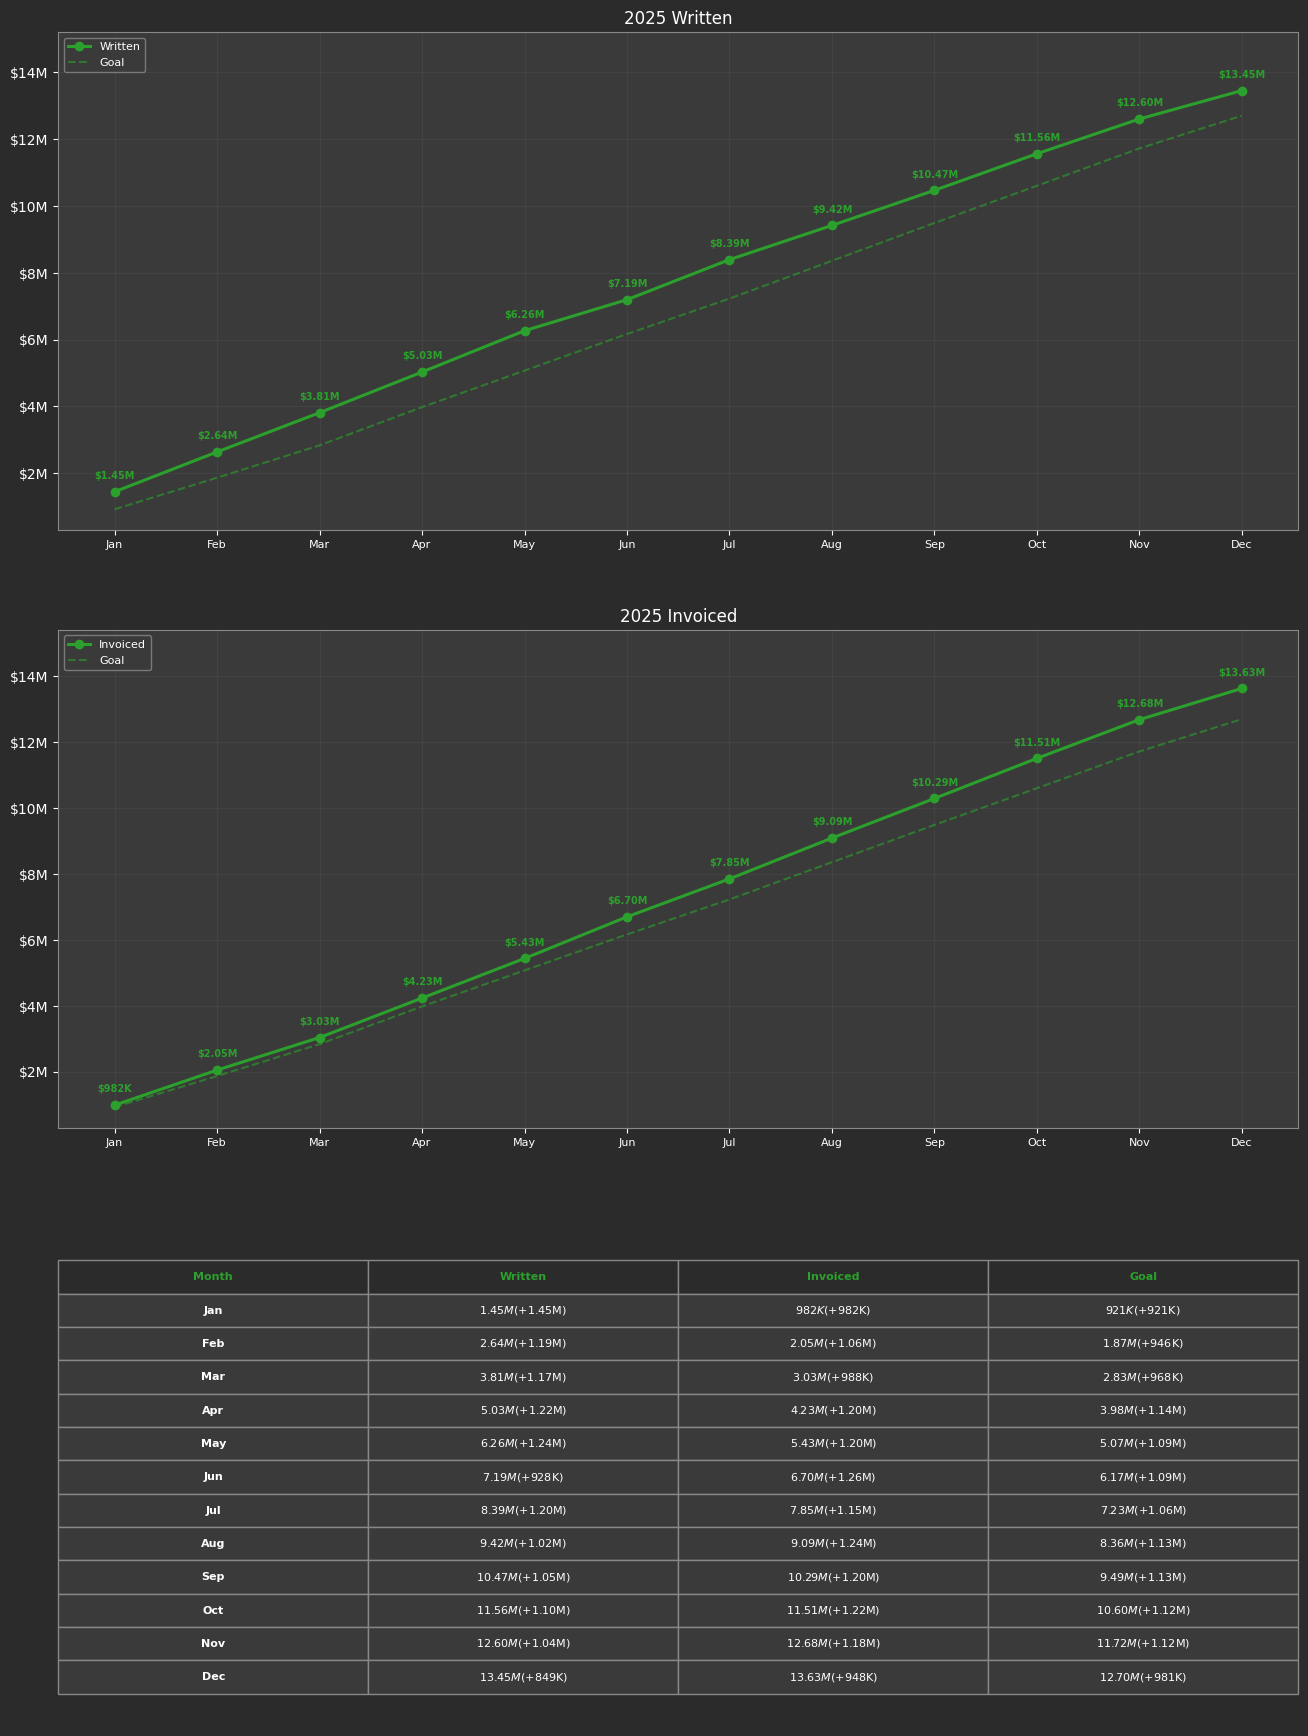

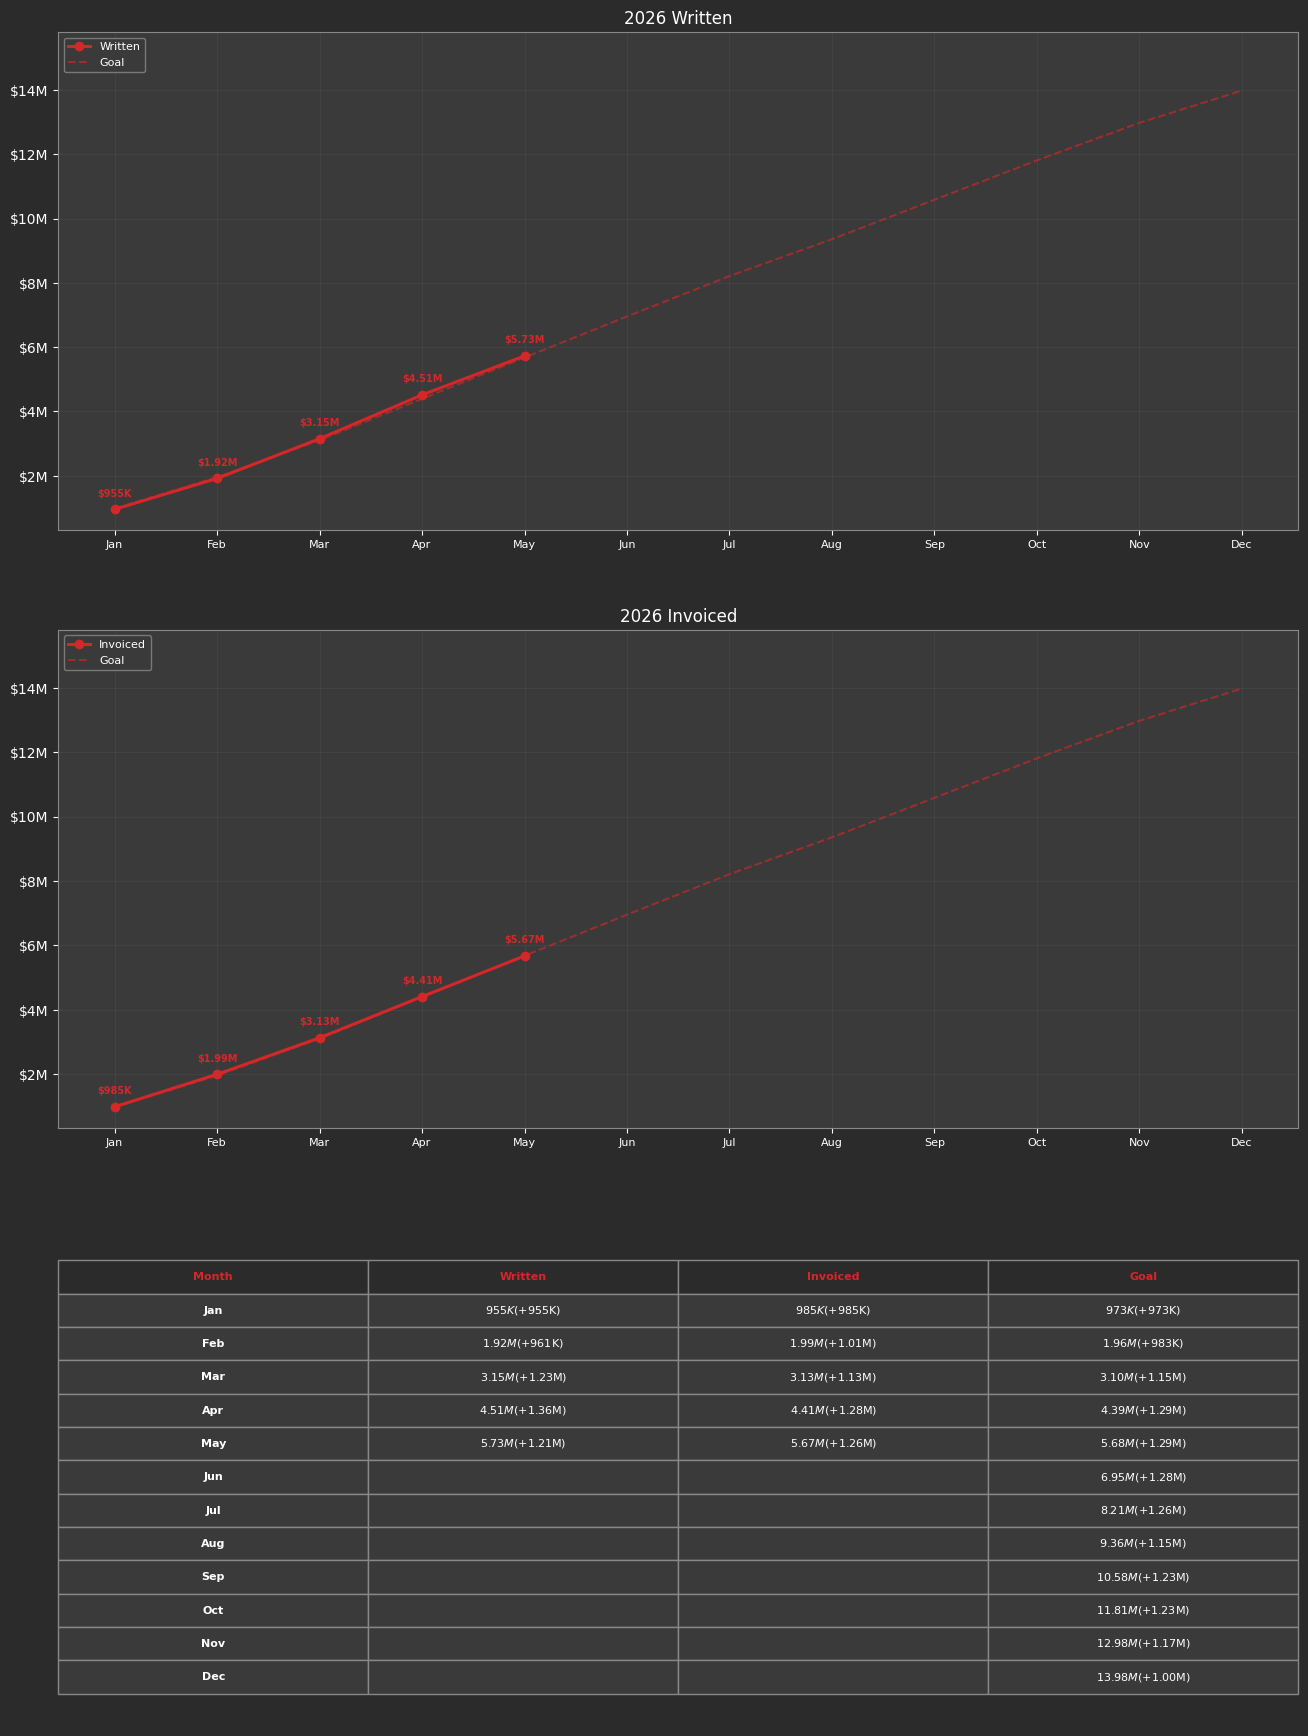

In [6]:
def fmt_cum(series):
    out = []
    prev = None
    for v in series:
        if v is None:
            out.append('')
        else:
            inc = v if prev is None else v - prev
            out.append(f'{fmt(v)} (+{fmt(inc)})')
            prev = v
    return out

for yr in years:
    fig = plt.figure(figsize=(16, 22))
    gs = fig.add_gridspec(3, 1)
    goal_traj = data[yr]['goal']
    for row, metric in enumerate(['written', 'invoiced']):
        ax = fig.add_subplot(gs[row, 0])
        series = data[yr][metric]
        pts = [v for v in series if v is not None]
        ax.plot(x[:len(pts)], pts, marker='o', linewidth=2.2,
                color=colors[yr], label=metric.capitalize())
        if all(v is not None for v in goal_traj):
            ax.plot(x, goal_traj, linestyle='--', linewidth=1.5,
                    color=colors[yr], alpha=0.6, label='Goal')
        for i, v in enumerate(pts):
            ax.annotate(fmt(v), xy=(i, v), xytext=(0, 8), textcoords='offset points', color=colors[yr], fontsize=7, ha='center', va='bottom', fontweight='bold')
        ax.set_title(f'{yr} {metric.capitalize()}')
        ax.set_xticks(x)
        ax.set_xticklabels(months, fontsize=8)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v/1e6:.0f}M'))
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left', facecolor='#3a3a3a', edgecolor='#888', labelcolor='white', fontsize=8)
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 1.08)
        
    tax = fig.add_subplot(gs[2, 0])
    tax.axis('off')
    col_labels = ['Month', 'Written', 'Invoiced', 'Goal']
    w_cells = fmt_cum(data[yr]['written'])
    i_cells = fmt_cum(data[yr]['invoiced'])
    g_cells = fmt_cum(goal_traj)
    cell_text = []
    for m in range(12):
        cell_text.append([months[m], w_cells[m], i_cells[m], g_cells[m]])
        
    table = tax.table(cellText=cell_text, colLabels=col_labels, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 2)
    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor('#888')
        if r == 0:
            cell.set_facecolor('#2b2b2b')
            cell.set_text_props(color=colors[yr], fontweight='bold')
        else:
            cell.set_facecolor('#3a3a3a')
            cell.set_text_props(color='white')
            if c == 0:
                cell.set_text_props(color='white', fontweight='bold')
    plt.show()

## Sales by Month Comparison
Non-cumulative bar chart to compare how each year's months stacked against eachother. Also able to visually discern if a year was more front or back heavy.

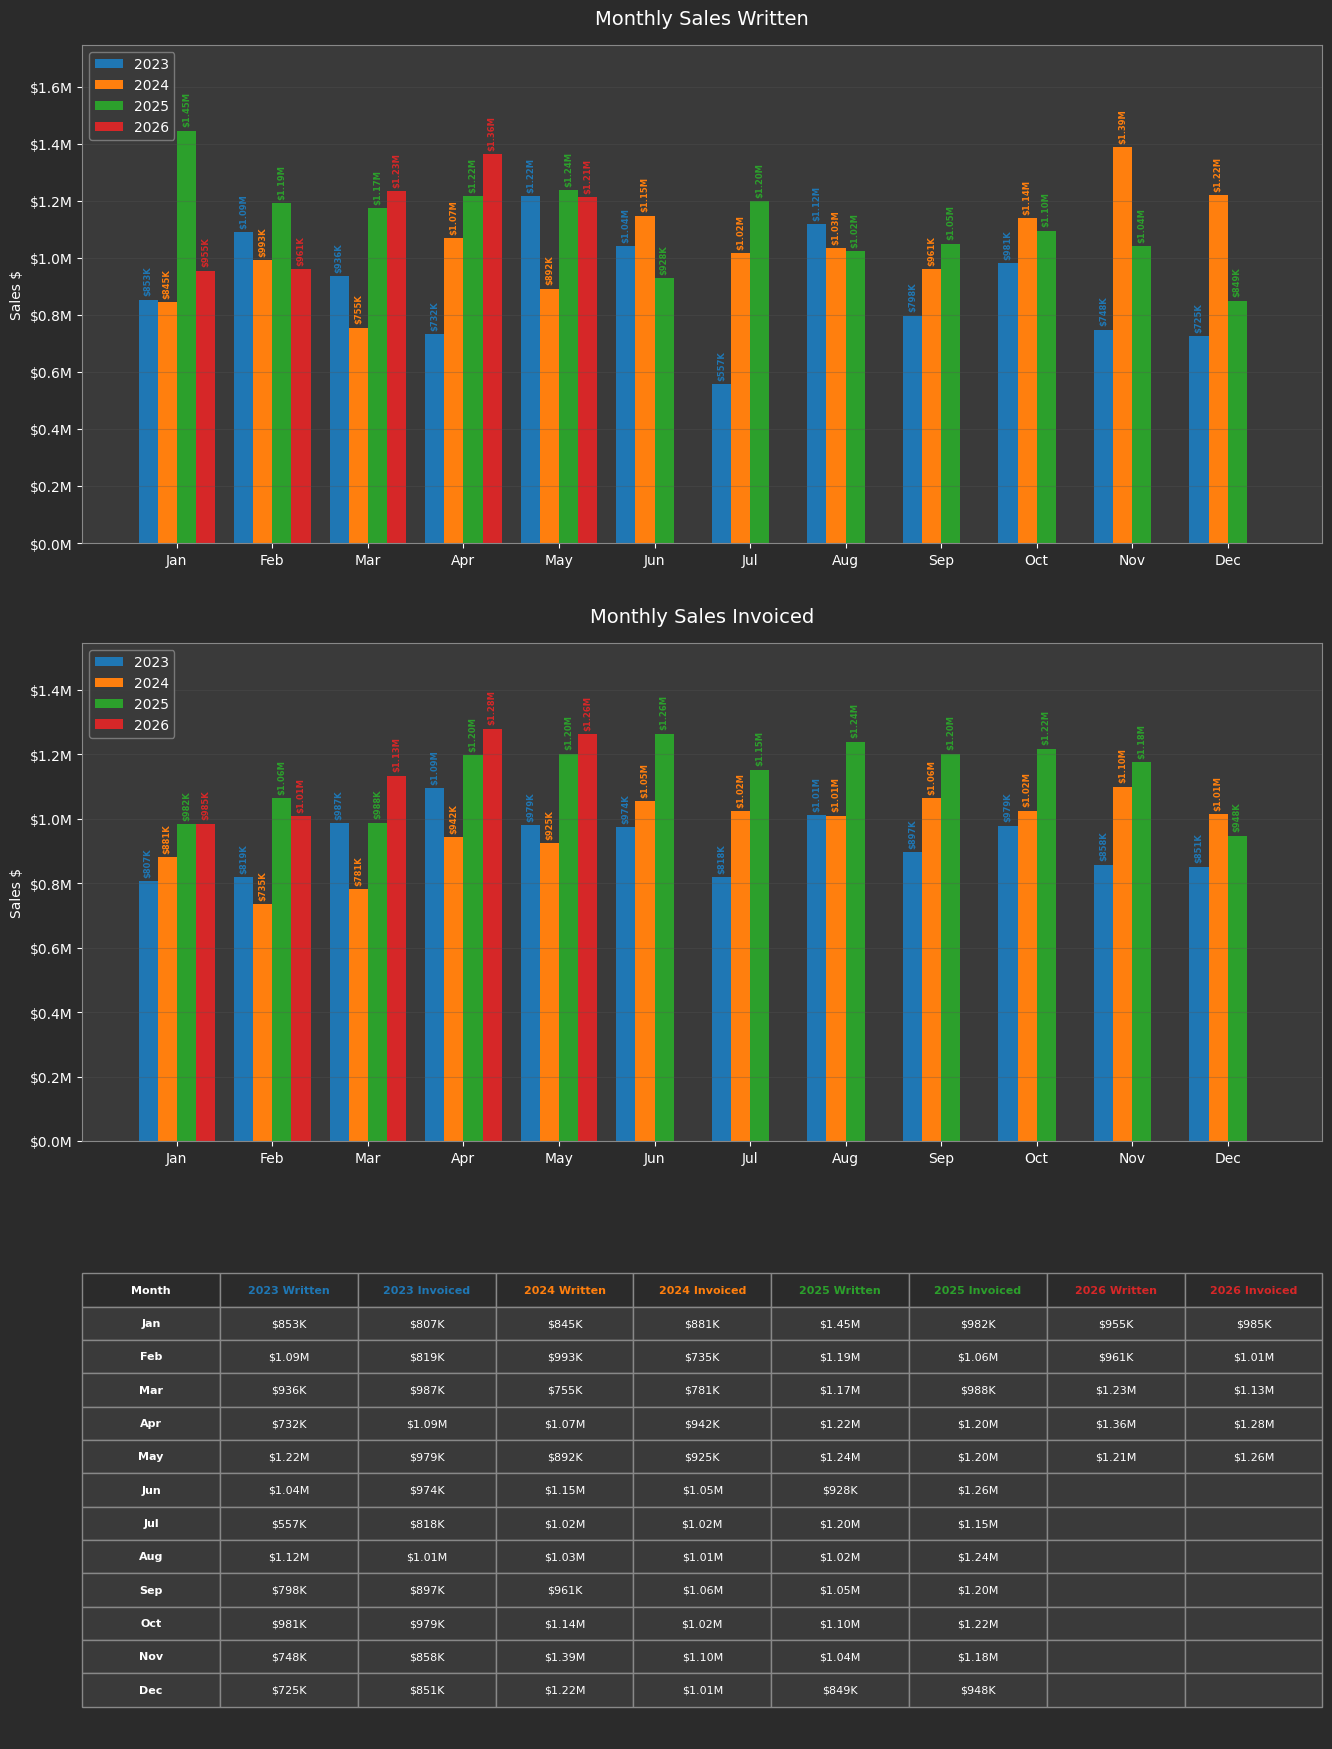

In [7]:
monthly_data = {'written': {}, 'invoiced': {}}
for metric in ['written', 'invoiced']:
    for yr in years:
        vals = [v for v in data[yr][metric] if v is not None]
        if not vals:
            monthly_data[metric][yr] = [None] * 12
            continue
        incr = [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]
        monthly_data[metric][yr] = incr + [None] * (12 - len(incr))
        
width = 0.8 / len(years)
fig = plt.figure(figsize=(16, 22))
gs = fig.add_gridspec(3, 1)
for row, metric in enumerate(['written', 'invoiced']):
    ax = fig.add_subplot(gs[row, 0])
    md = monthly_data[metric]
    for i, yr in enumerate(years):
        offsets = x + (i - (len(years) - 1) / 2) * width
        vals = [v if v is not None else 0 for v in md[yr]]
        ax.bar(offsets, vals, width, label=str(yr), color=colors[yr])
        for xi, (raw, v) in enumerate(zip(md[yr], vals)):
            if raw is None:
                continue
            ax.annotate(fmt(v), xy=(offsets[xi], v), xytext=(0, 3), textcoords='offset points', rotation=90, color=colors[yr], fontsize=6, ha='center', va='bottom', fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(months)
    ax.set_title(f'Monthly Sales {metric.capitalize()}', fontsize=14, pad=15)
    ax.set_ylabel('Sales $')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'))
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(loc='upper left', facecolor='#3a3a3a', edgecolor='#888', labelcolor='white')
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.15)
    
tax = fig.add_subplot(gs[2, 0])
tax.axis('off')
col_labels = ['Month']
col_colors = ['white']
for yr in years:
    col_labels += [f'{yr} Written', f'{yr} Invoiced']
    col_colors += [colors[yr], colors[yr]]
    
cell_text = []
for m in range(12):
    row = [months[m]]
    for yr in years:
        w = monthly_data['written'][yr][m]
        iv = monthly_data['invoiced'][yr][m]
        row.append('' if w is None else fmt(w))
        row.append('' if iv is None else fmt(iv))
    cell_text.append(row)
    
table = tax.table(cellText=cell_text, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#888')
    if r == 0:
        cell.set_facecolor('#2b2b2b')
        cell.set_text_props(color=col_colors[c], fontweight='bold')
    else:
        cell.set_facecolor('#3a3a3a')
        cell.set_text_props(color='white', fontweight='bold' if c == 0 else 'normal')

plt.show()